In [25]:
# Load dataset

!git clone https://github.com/Aadi22204/personal-finance-intelligence.git

fatal: destination path 'personal-finance-intelligence' already exists and is not an empty directory.


In [26]:
# import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Load dataset
df=pd.read_csv("personal-finance-intelligence/data/transactions.csv")
df["date"] = pd.to_datetime(df["date"])
df.head()

,id,date,type,category,amount,description
0,1,2026-09-01,Income,Salary,30000,Monthly salary
1,2,2026-09-02,Expense,Food,250,Lunch
2,3,2026-09-03,Expense,Travel,500,Cab to college
3,4,2026-09-04,Expense,Shopping,1200,Clothes
4,5,2026-09-05,Expense,Food,180,Breakfast


In [27]:
# separate income and expense
income=df[df['type']=='Income']
expenses=df[df['type']=='Expense']

total_income = income["amount"].sum()
total_expense = expenses["amount"].sum()

print("Total Income:", total_income)
print("Total Expense:", total_expense)

Total Income: 103000
Total Expense: 28200


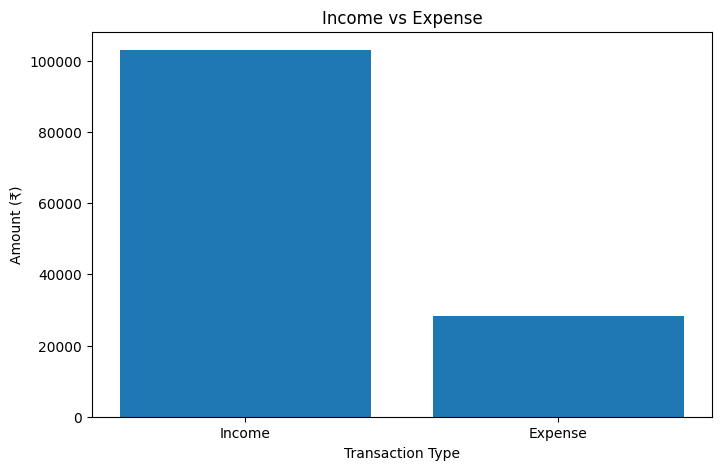

In [28]:
# visulation income vs expense
labels = ["Income", "Expense"]
values = [total_income, total_expense]

plt.figure(figsize=(8, 5))

plt.bar(labels, values)

plt.title("Income vs Expense")
plt.xlabel("Transaction Type")
plt.ylabel("Amount (₹)")

plt.show()

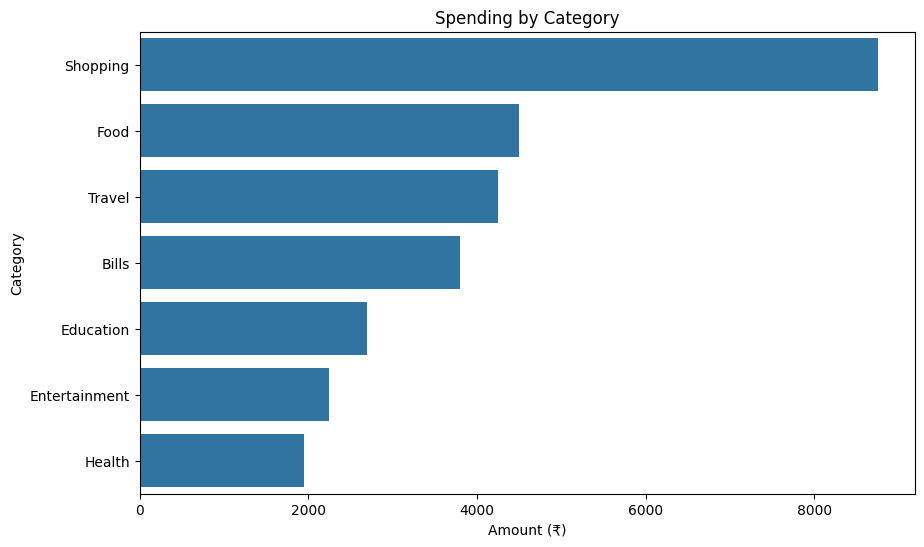

In [29]:
# visualization spending by category
category_spending = (
    expenses
    .groupby("category")["amount"]
    .sum()
    .sort_values(ascending=False)
)



plt.figure(figsize=(10, 6))

sns.barplot(
    x=category_spending.values,
    y=category_spending.index
)

plt.title("Spending by Category")
plt.xlabel("Amount (₹)")
plt.ylabel("Category")

plt.show()

In [32]:
# monthly financial data

df["month"] = df["date"].dt.to_period("M")
income = df[df["type"] == "Income"]
expenses = df[df["type"] == "Expense"]

monthly_income = (
    income.groupby("month")["amount"]
    .sum()
)

monthly_expense = (
    expenses.groupby("month")["amount"]
    .sum()
)


monthly_summary = pd.DataFrame({
    "income": monthly_income,
    "expense": monthly_expense
})

monthly_summary["savings"] = (
    monthly_summary["income"]
    - monthly_summary["expense"]
)

monthly_summary["savings_rate"] = (
    monthly_summary["savings"]
    / monthly_summary["income"]
) * 100

monthly_summary["savings_rate"] = (
    monthly_summary["savings_rate"].round(2)
)

monthly_summary

,income,expense,savings,savings_rate
month,,,,
2026-09,35000,10870,24130,68.94
2026-10,33500,11600,21900,65.37
2026-11,34500,5730,28770,83.39


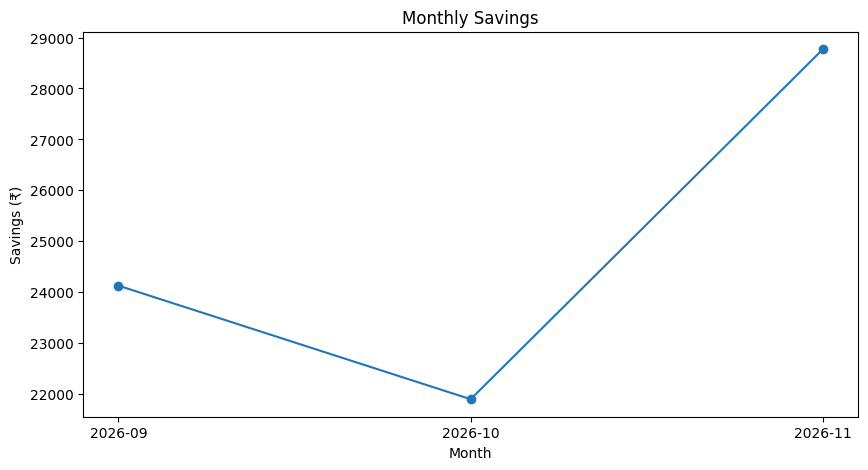

In [33]:
# visualization montly saving
plt.figure(figsize=(10, 5))

plt.plot(
    monthly_summary.index.astype(str),
    monthly_summary["savings"],
    marker="o"
)

plt.title("Monthly Savings")
plt.xlabel("Month")
plt.ylabel("Savings (₹)")

plt.show()


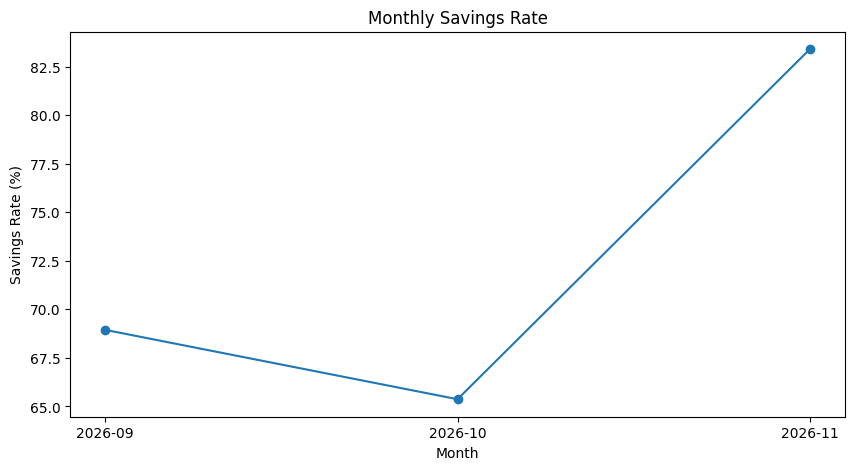

In [34]:
# visualization monthly saving rate
plt.figure(figsize=(10, 5))

plt.plot(
    monthly_summary.index.astype(str),
    monthly_summary["savings_rate"],
    marker="o"
)

plt.title("Monthly Savings Rate")
plt.xlabel("Month")
plt.ylabel("Savings Rate (%)")

plt.show()

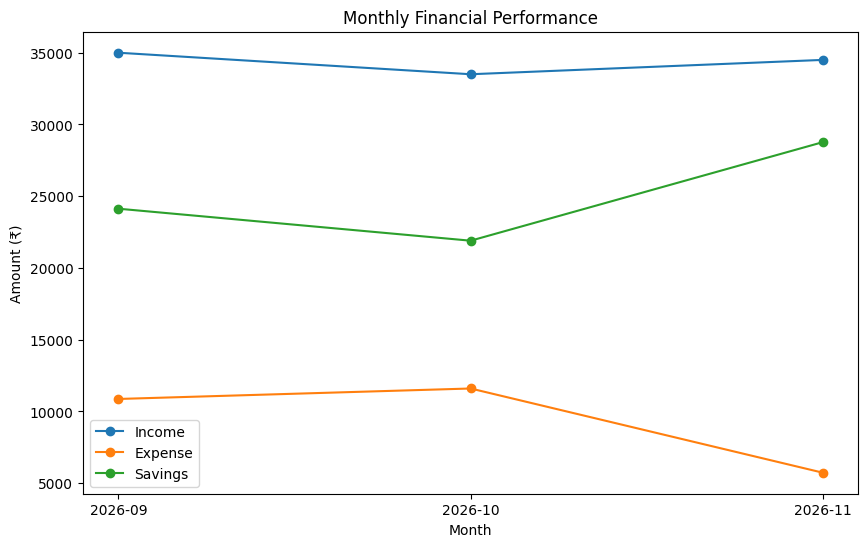

In [36]:
# combined monthly chart
plt.figure(figsize=(10, 6))

plt.plot(
    monthly_summary.index.astype(str),
    monthly_summary["income"],
    marker="o",
    label="Income"
)

plt.plot(
    monthly_summary.index.astype(str),
    monthly_summary["expense"],
    marker="o",
    label="Expense"
)

plt.plot(
    monthly_summary.index.astype(str),
    monthly_summary["savings"],
    marker="o",
    label="Savings"
)

plt.title("Monthly Financial Performance")
plt.xlabel("Month")
plt.ylabel("Amount (₹)")

plt.legend()

plt.show()